Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

sns.set_style("whitegrid")

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8,5)

Load & Extract Data

In [ ]:
def extract_zip(zip_path, extract_path="/content/data"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    return extract_path


def load_csv_from_folder(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            print(f"Loading file: {file}")
            return pd.read_csv(file_path, encoding='ISO-8859-1')


# Extract & load
data_path = extract_zip("/content/archive (3).zip")
df = load_csv_from_folder(data_path)

Loading file: online_retail.csv


Data Cleaning

In [ ]:
def clean_data(df):
    df = df.dropna(subset=['CustomerID'])
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    return df

df = clean_data(df)

Feature Engineering

In [ ]:
def add_features(df):
    df['Revenue'] = df['Quantity'] * df['UnitPrice']
    return df

df = add_features(df)

Customer Aggregation (RFM)

In [ ]:
def create_customer_data(df):
    customer_revenue = df.groupby('CustomerID')['Revenue'].sum()
    customer_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()

    latest_date = df['InvoiceDate'].max()
    customer_recency = df.groupby('CustomerID')['InvoiceDate'].max()
    customer_recency = (latest_date - customer_recency).dt.days

    customer_data = pd.DataFrame({
        'Revenue': customer_revenue,
        'Frequency': customer_freq,
        'Recency': customer_recency
    })

    return customer_data

customer_data = create_customer_data(df)

RFM Scoring

In [ ]:
def rfm_scoring(customer_data):
    customer_data['R_score'] = pd.qcut(customer_data['Recency'], 4, labels=[4,3,2,1])
    customer_data['F_score'] = pd.qcut(customer_data['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
    customer_data['M_score'] = pd.qcut(customer_data['Revenue'], 4, labels=[1,2,3,4])

    customer_data['RFM_Score'] = (
        customer_data['R_score'].astype(str) +
        customer_data['F_score'].astype(str) +
        customer_data['M_score'].astype(str)
    )

    return customer_data

customer_data = rfm_scoring(customer_data)

Customer Segmentation

In [ ]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Best Customer'
    elif row['R_score'] == 4:
        return 'Loyal Customer'
    elif row['M_score'] == 4:
        return 'Big Spender'
    else:
        return 'Regular'

customer_data['Segment'] = customer_data.apply(segment_customer, axis=1)

Visualization

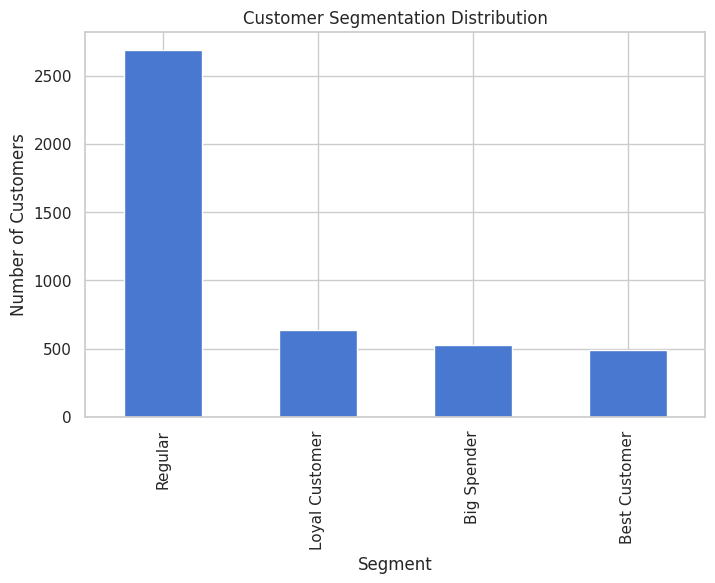

In [ ]:
def plot_segment_distribution(customer_data):
    plt.figure()
    customer_data['Segment'].value_counts().plot(kind='bar')
    plt.title("Customer Segmentation Distribution")
    plt.xlabel("Segment")
    plt.ylabel("Number of Customers")
    plt.show()

plot_segment_distribution(customer_data)

Output Summary

In [ ]:
print("\nCustomer Segment Distribution:")
print(customer_data['Segment'].value_counts())


Customer Segment Distribution:
Segment
Regular           2687
Loyal Customer     635
Big Spender        526
Best Customer      490
Name: count, dtype: int64


Distribution Revenue

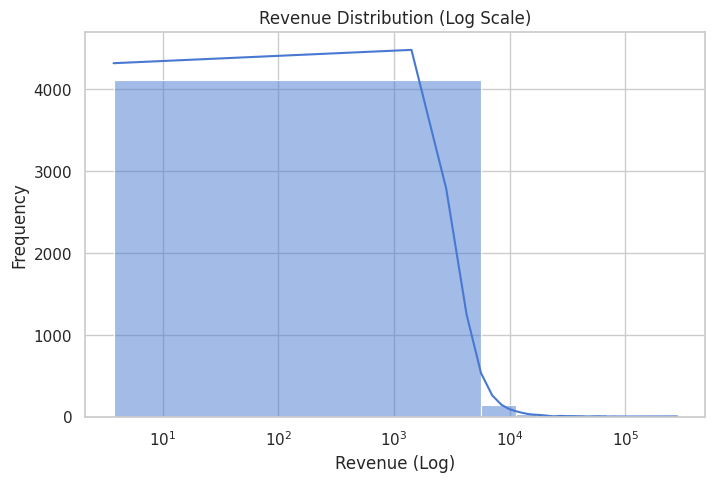

In [ ]:
plt.figure()
sns.histplot(customer_data['Revenue'], bins=50, kde=True)
plt.xscale('log')
plt.title("Revenue Distribution (Log Scale)")
plt.xlabel("Revenue (Log)")
plt.ylabel("Frequency")
plt.show()

Frequency vs Revenue

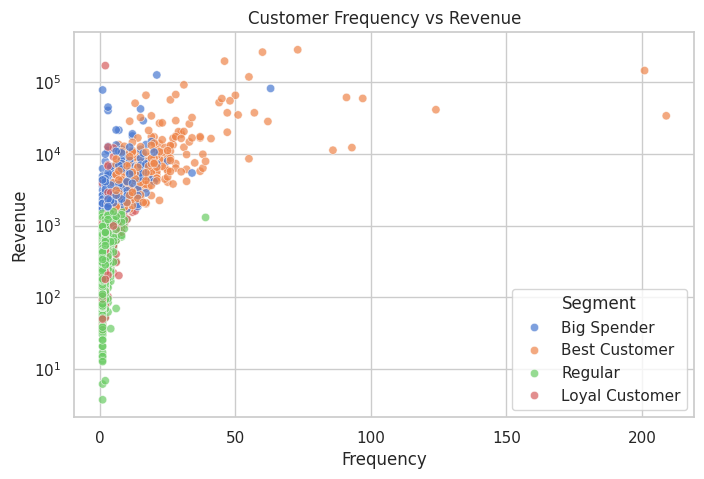

In [ ]:
plt.figure()
sns.scatterplot(
    x='Frequency',
    y='Revenue',
    data=customer_data,
    hue='Segment',
    alpha=0.7
)
plt.yscale('log')
plt.title("Customer Frequency vs Revenue")
plt.show()

Boxplot per Segment

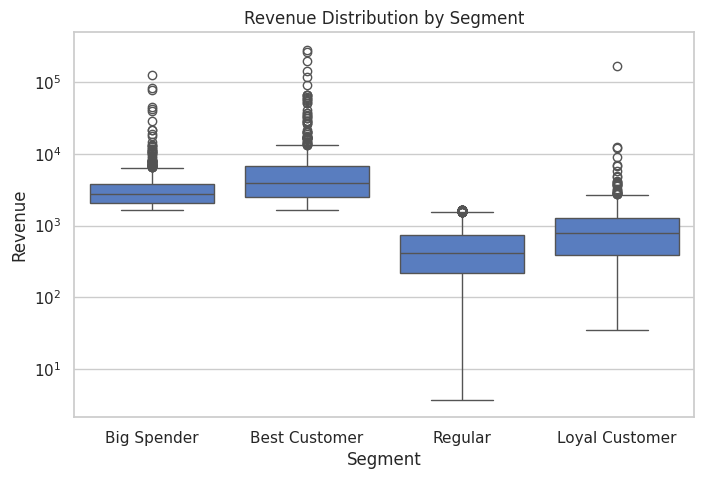

In [ ]:
plt.figure()
sns.boxplot(
    x='Segment',
    y='Revenue',
    data=customer_data
)
plt.yscale('log')
plt.title("Revenue Distribution by Segment")
plt.show()

Recency vs Frequency (Customer Behavior)

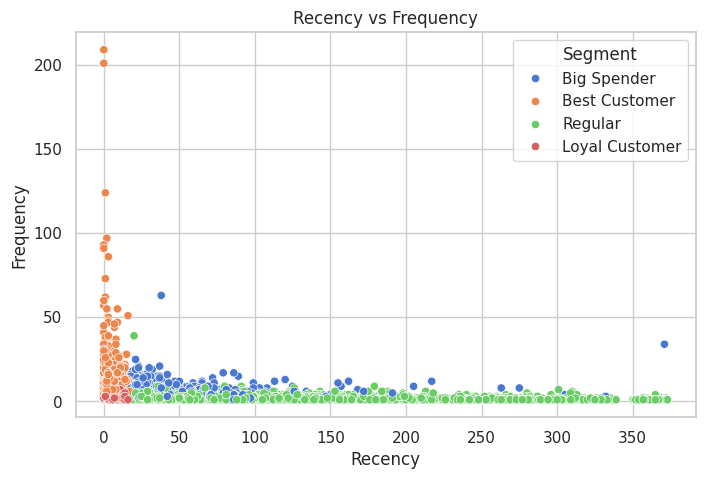

In [ ]:
plt.figure()
sns.scatterplot(
    x='Recency',
    y='Frequency',
    data=customer_data,
    hue='Segment'
)
plt.title("Recency vs Frequency")
plt.show()

Heatmap

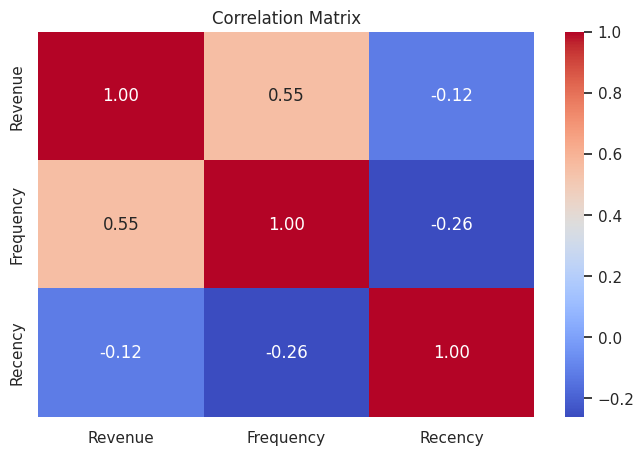

In [ ]:
plt.figure()
corr = customer_data[['Revenue', 'Frequency', 'Recency']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Segment Composition

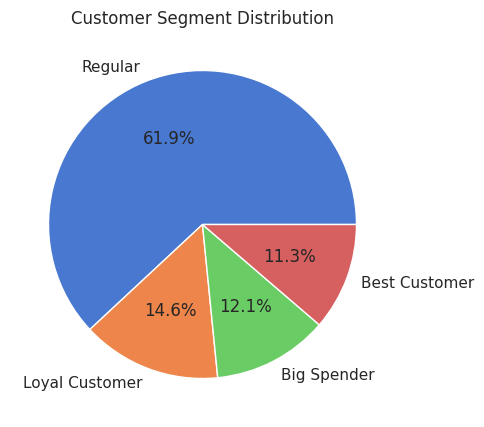

In [ ]:
segment_counts = customer_data['Segment'].value_counts()

plt.figure()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
plt.title("Customer Segment Distribution")
plt.show()